# Posterior for E. coli local recombination rate and mutation rate using SBI

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from Bio import Phylo
import seaborn as sns
import torch
from torch.distributions import Uniform
import sbi
from sbi.utils.user_input_checks import MultipleIndependent
from sbi.neural_nets import posterior_nn
from sbi.inference import NPE_C
from sbi.analysis import plot_summary
import sys
sys.path.append('../pysimARG')
from discrete_uniform import DiscreteUniform
from LeaveLengthOut_NN import LeaveLengthOut_NN

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load simulation data

Load bacillus gene data and clonal tree.

In [2]:
# Load phylo tree and convert to ClonalTree format
phylo_tree = Phylo.read("../data/ecoli/ecoli_clonal.nwk", "newick")
Phylo.draw_ascii(phylo_tree)

                                          ______________________________ 8
                                         |
  _______________________________________|          ____________________ 0
 |                                       |         |
 |                                       |         |                    , 21
 |                                       |_________|    ________________|
 |                                                 |   |                , 2
 |                                                 |   |                |
 |                                                 |___|                | 26
 |                                                     |
 |                                                     |   _____________ 7
 |                                                     |__|
 |                                                        |_____________ 10
 |
_|                                                                    __ 20
 |                           

In [3]:
x_obs_info_table = pd.read_csv("../data/ecoli/ecoli_block_info.csv", index_col=0)
x_obs_info_table.head()

,Gene_Length,Start_pos,End_pos,Alignment
Gene_ID,,,,
0,1200,605790,606989,True
1,1724,614003,615726,True
2,4601,616186,620786,True
3,6950,606990,613939,True
4,3797,601974,605770,True


In [4]:
drop_col = range(16, 32)

In [5]:
x_obs_df = pd.read_csv("../data/ecoli/ecoli_block_summary_stats.csv", header=None)
x_obs_np = x_obs_df.to_numpy()
x_obs_np = np.delete(x_obs_np, drop_col, axis=1)
x_obs_torch = torch.tensor(x_obs_np, device=torch_device)
x_obs_torch = x_obs_torch.to(torch.float32)
x_obs_torch.shape, x_obs_torch.dtype

(torch.Size([836, 30]), torch.float32)

### Delete observations with no signal

In [6]:
x_obs_info_table

,Gene_Length,Start_pos,End_pos,Alignment
Gene_ID,,,,
0,1200,605790,606989,True
1,1724,614003,615726,True
2,4601,616186,620786,True
3,6950,606990,613939,True
4,3797,601974,605770,True
...,...,...,...,...
761_0,5476,1504811,1510286,True
761_1,5475,1510287,1515761,True
762,4170,1541972,1546141,True


In [7]:
too_large_length = np.where(x_obs_info_table['Gene_Length'] > 10000)[0]
too_large_length

array([], dtype=int64)

In [8]:
no_signal_id = np.where(x_obs_np[:, 17] == 0)[0]
no_signal_id.shape, no_signal_id[:10]

((0,), array([], dtype=int64))

Ignore the observations that have too large gene length. But there is no observations with no signal.

## Load simulation data

In [9]:
theta1 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta1.csv', delimiter=",")
x1 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x1.csv', delimiter=",")
nrow1 = x1.shape[0]

theta2 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta2.csv', delimiter=",")
x2 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x2.csv', delimiter=",")
nrow2 = x2.shape[0]

theta3 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta3.csv', delimiter=",")
x3 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x3.csv', delimiter=",")
nrow3 = x3.shape[0]

theta4 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta4.csv', delimiter=",")
x4 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x4.csv', delimiter=",")
nrow4 = x4.shape[0]

theta5 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta5.csv', delimiter=",")
x5 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x5.csv', delimiter=",")
nrow5 = x5.shape[0]

theta6 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta6.csv', delimiter=",")
x6 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x6.csv', delimiter=",")
nrow6 = x6.shape[0]

theta7 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta7.csv', delimiter=",")
x7 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x7.csv', delimiter=",")
nrow7 = x7.shape[0]

theta8 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta8.csv', delimiter=",")
x8 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x8.csv', delimiter=",")
nrow8 = x8.shape[0]

theta9 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta9.csv', delimiter=",")
x9 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x9.csv', delimiter=",")
nrow9 = x9.shape[0]

theta10 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta10.csv', delimiter=",")
x10 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x10.csv', delimiter=",")
nrow10 = x10.shape[0]

x = np.vstack([x1, x2, x3, x4, x5, x6, x7, x8, x9, x10])
x = np.delete(x, drop_col, axis=1)
theta = np.vstack([theta1[:nrow1], theta2[:nrow2], theta3[:nrow3], theta4[:nrow4], theta5[:nrow5],
                   theta6[:nrow6], theta7[:nrow7], theta8[:nrow8], theta9[:nrow9], theta10[:nrow10]])

print(theta.shape, x.shape)

(57100, 3) (57100, 30)


In [10]:
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()

x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()

### Find out-of-range observations

In [11]:
ignore_indices = []
no_segregation = []
out_stats = dict()
for i in range(x_obs_torch.shape[0]):
    ignore_i = False
    out_index = []
    for j in range(30):
        max_j = torch.max(x[:, j])
        min_j = torch.min(x[:, j])
        obs_j = x_obs_torch[i, j]
        if obs_j < min_j or obs_j > max_j:
            ignore_i = True
            out_index.append(j)
        if j == 17 and obs_j == 0:
            no_segregation.append(i)
    if ignore_i or torch.isnan(x_obs_torch[i, :]).any():
        print(f"Observation {i} is outside the range of simulated data.")
        ignore_indices.append(i)
        out_stats[i] = out_index

Observation 5 is outside the range of simulated data.
Observation 22 is outside the range of simulated data.
Observation 31 is outside the range of simulated data.
Observation 38 is outside the range of simulated data.
Observation 57 is outside the range of simulated data.
Observation 60 is outside the range of simulated data.
Observation 63 is outside the range of simulated data.
Observation 108 is outside the range of simulated data.
Observation 120 is outside the range of simulated data.
Observation 136 is outside the range of simulated data.
Observation 146 is outside the range of simulated data.
Observation 149 is outside the range of simulated data.
Observation 162 is outside the range of simulated data.
Observation 164 is outside the range of simulated data.
Observation 261 is outside the range of simulated data.
Observation 308 is outside the range of simulated data.
Observation 345 is outside the range of simulated data.
Observation 362 is outside the range of simulated data.


In [12]:
len(ignore_indices), len(no_segregation), len(out_stats)

(35, 0, 35)

In [13]:
out_index_all = []
for i in range(len(ignore_indices)):
    idx = ignore_indices[i]
    out_index_all += out_stats[idx]

In [14]:
from collections import Counter

integer_counts = Counter(out_index_all)

In [15]:
for i in range(30):
    print(f"Index {i}: {integer_counts[i]}")

Index 0: 0
Index 1: 0
Index 2: 0
Index 3: 0
Index 4: 0
Index 5: 0
Index 6: 0
Index 7: 0
Index 8: 11
Index 9: 5
Index 10: 0
Index 11: 0
Index 12: 15
Index 13: 6
Index 14: 0
Index 15: 0
Index 16: 0
Index 17: 0
Index 18: 0
Index 19: 0
Index 20: 0
Index 21: 0
Index 22: 35
Index 23: 21
Index 24: 0
Index 25: 14
Index 26: 0
Index 27: 0
Index 28: 0
Index 29: 0


## NPE

### Create prior to pass range knowledge to NPE

In [16]:
prior_rho = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.2]))
prior_theta = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.1]))
prior_L = DiscreteUniform(low=torch.tensor([100.0]), high=torch.tensor([10000.0]))

prior = MultipleIndependent(
    dists=[prior_rho, prior_theta, prior_L],
    validate_args=False,
    device=torch_device
)

### Using all simulations

In [17]:
embedding_net = LeaveLengthOut_NN(
    input_dim=30,
    num_hiddens=128,
    num_hidden_layers=1,
    num_outputs=2)
neural_posterior = posterior_nn(
    model="nsf",
    embedding_net=embedding_net,
    hidden_features=30,
    num_transforms=8,
    num_bins=5,
    z_score_theta="independent",
    z_score_x="independent"
)

In [18]:
seed = 100
num_posterior_samples=1000

inference = NPE_C(density_estimator=neural_posterior, device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [19]:
# density_estimator = inference.append_simulations(theta, x).train(
#     max_num_epochs=500,
#     training_batch_size=100,
#     learning_rate=0.0001,
#     stop_after_epochs=20,
#     clip_max_norm=None
# )
# posterior = inference.build_posterior(density_estimator)

In [20]:
# fig, axes = plot_summary(
#     inference, 
#     tags=["training_loss", "validation_loss"], 
#     figsize=(8, 4)
# )
# plt.title("Training and Validation Loss")
# plt.show()

### Save the trained NPE

In [21]:
save_path = "../data/ecoli/trained_npe_posterior.pt"

# torch.save(
#     {
#         "posterior": posterior,
#         "sbi_version": sbi.__version__,
#         "seed": seed,
#         "learning_rate": 0.0001,
#         "max_num_epochs": 500,
#     },
#     save_path,
# )

In [22]:
checkpoint = torch.load(save_path, map_location="cpu")
posterior = checkpoint["posterior"]

C:\Users\u2008181\AppData\Local\Temp\ipykernel_17388\1569981112.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(save_path, map_location="cpu")


### Plug in observation data to get posterior

In [82]:
theta_post = np.full((x_obs_torch.shape[0], num_posterior_samples, 3), np.nan)
theta_post.shape

(836, 1000, 3)

In [83]:
for i in range(x_obs_torch.shape[0]):
    # if i in ignore_indices:
    #     continue

    theta_post_torch = posterior.sample((num_posterior_samples,), x=x_obs_torch[i, :],
                                        show_progress_bars=False, reject_outside_prior=True)
    theta_post[i, :, :] = theta_post_torch.cpu().detach().numpy()

C:\Users\u2008181\AppData\Local\Temp\ipykernel_17388\3530236854.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


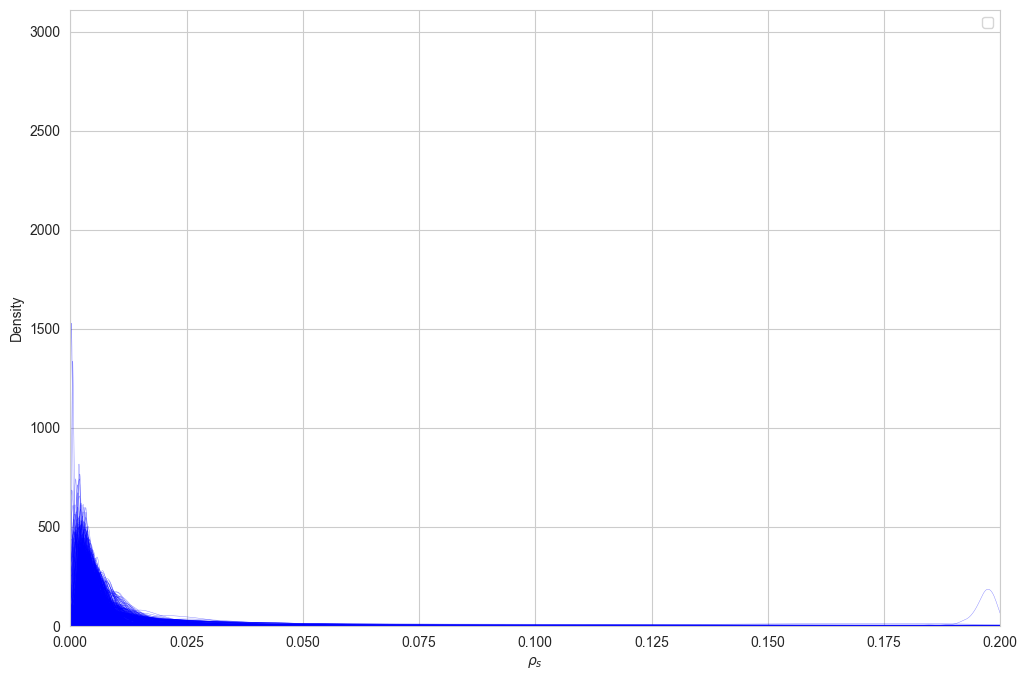

In [ ]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
for i in range(0, x_obs_torch.shape[0]):
    # if i in ignore_indices:
    #     continue
    sns.kdeplot(theta_post[i, :, 0], color='blue', linewidth=0.3, alpha=0.5)
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.2)
plt.legend()
plt.show()

C:\Users\u2008181\AppData\Local\Temp\ipykernel_17388\4043880167.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


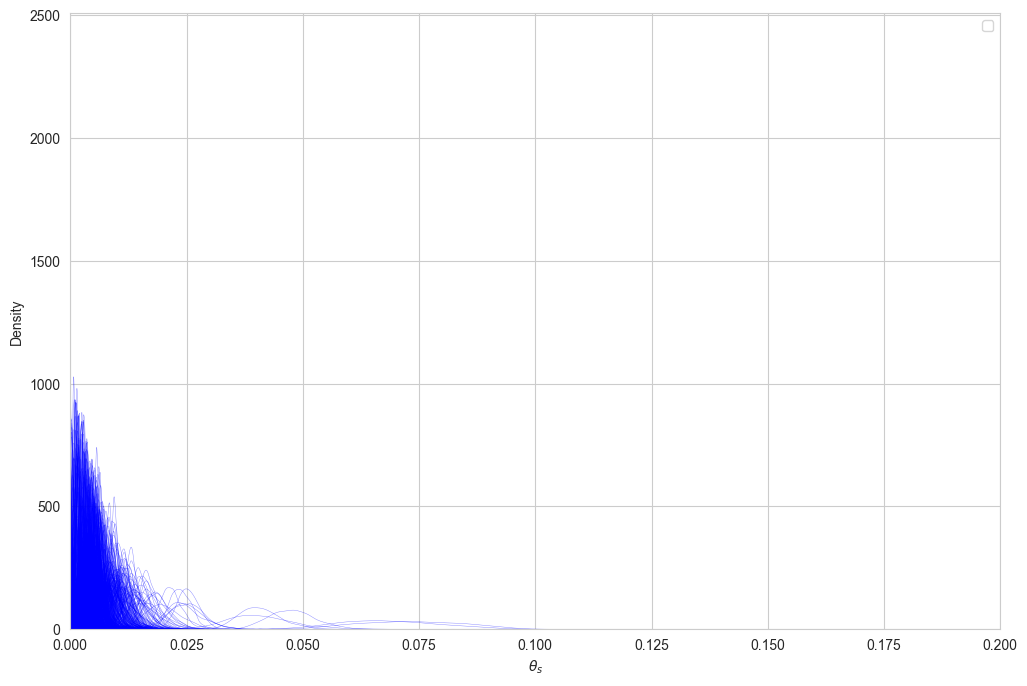

In [26]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
for i in range(0, x_obs_torch.shape[0]):
    # if i in ignore_indices:
    #     continue
    sns.kdeplot(theta_post[i, :, 1], color='blue', linewidth=0.3, alpha=0.5)
plt.xlabel(r'$\theta_s$')
plt.xlim(0.0, 0.2)
plt.legend()
plt.show()

### Plot bar plots by position

In [113]:
x_obs_info_table

,Gene_Length,Start_pos,End_pos,Alignment
Gene_ID,,,,
0,1200,605790,606989,True
1,1724,614003,615726,True
2,4601,616186,620786,True
3,6950,606990,613939,True
4,3797,601974,605770,True
...,...,...,...,...
761_0,5476,1504811,1510286,True
761_1,5475,1510287,1515761,True
762,4170,1541972,1546141,True


In [114]:
plot_xlim = [0.0, 4938906.0]
samples_x = x_obs_info_table['Start_pos'].values

In [115]:
posterior_median = np.median(theta_post[:, :, 0], axis=1)
posterior_median.shape, posterior_median.shape

((836,), (836,))

In [116]:
ci_lower_bounds = np.percentile(theta_post[:, :, 0], 2.5, axis=1)
ci_upper_bounds = np.percentile(theta_post[:, :, 0], 97.5, axis=1)
ci_lower_bounds.shape, ci_upper_bounds.shape

((836,), (836,))

In [117]:
lower_errors = posterior_median - ci_lower_bounds
upper_errors = ci_upper_bounds - posterior_median
yerr = [lower_errors, upper_errors]

In [118]:
median_rho = np.median(posterior_median)
median_rho

np.float64(0.004985043895430863)

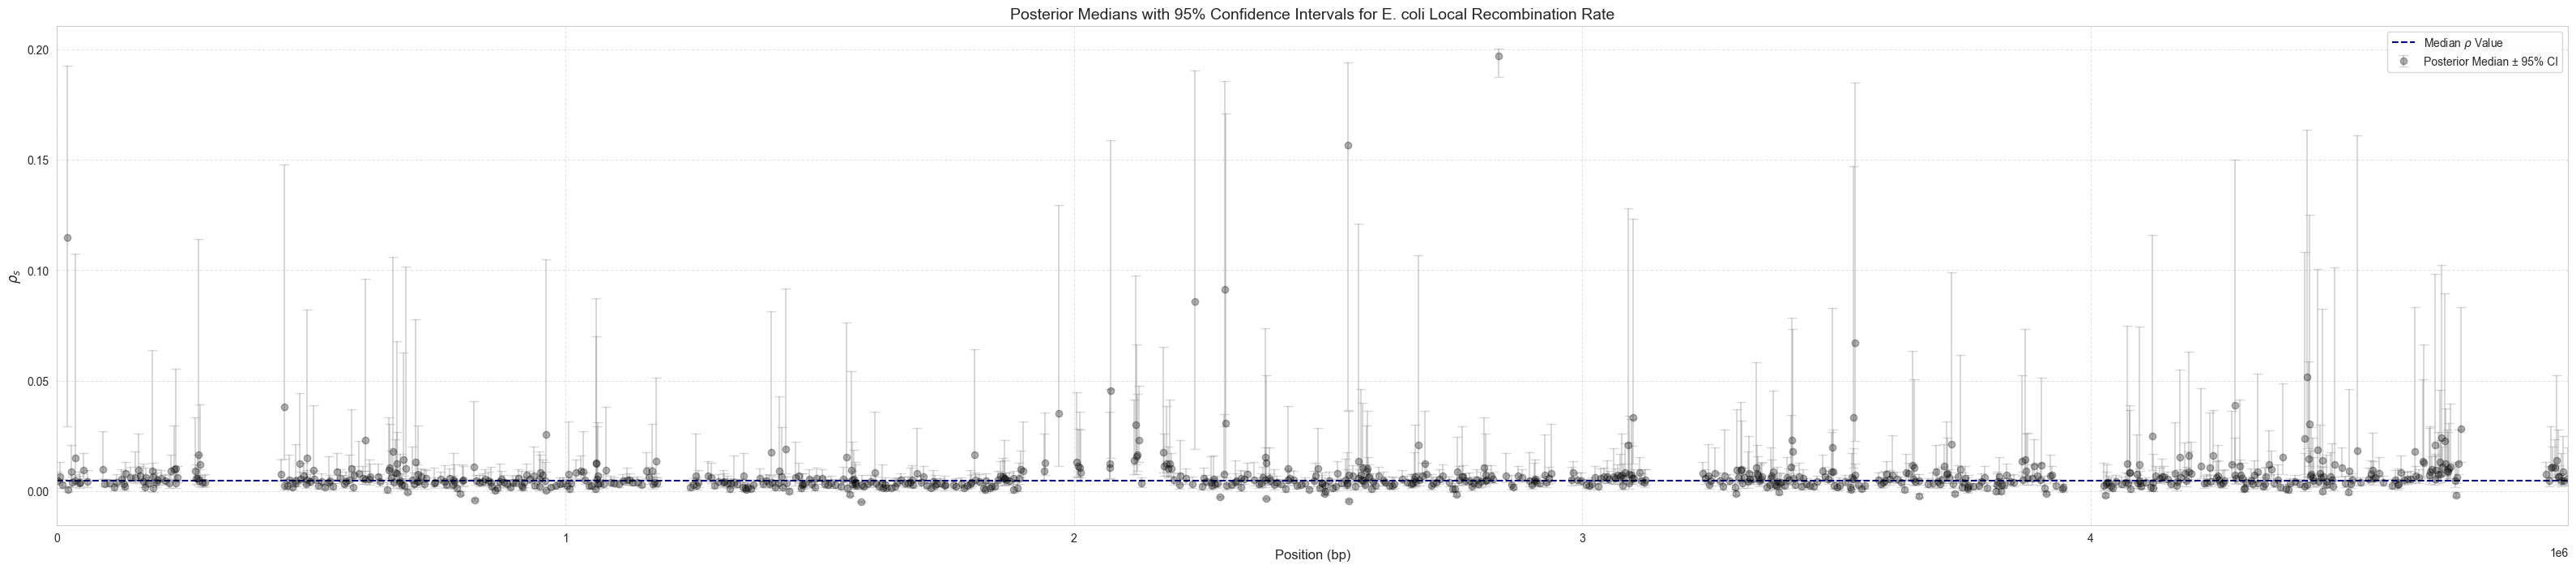

In [119]:
plt.figure(figsize=(40, 8))
plt.errorbar(samples_x, posterior_median, yerr=yerr, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, alpha=0.3,
             label='Posterior Median ± 95% CI')

plt.title("Posterior Medians with 95% Confidence Intervals for E. coli Local Recombination Rate", fontsize=14)
plt.xlabel("Position (bp)", fontsize=12)
plt.ylabel(r'$\rho_s$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(y=median_rho, color='darkblue', linestyle='dashed', label=r'Median $\rho$ Value')
plt.xlim(plot_xlim)
plt.legend()
plt.show()

In [120]:
posterior_median_theta = np.median(theta_post[:, :, 1], axis=1)
posterior_median_theta.shape, posterior_median_theta.shape

((836,), (836,))

In [121]:
ci_lower_bounds_theta = np.percentile(theta_post[:, :, 1], 2.5, axis=1)
ci_upper_bounds_theta = np.percentile(theta_post[:, :, 1], 97.5, axis=1)
ci_lower_bounds_theta.shape, ci_upper_bounds_theta.shape

((836,), (836,))

In [122]:
lower_errors_theta = posterior_median_theta - ci_lower_bounds_theta
upper_errors_theta = ci_upper_bounds_theta - posterior_median_theta
yerr_theta = [lower_errors_theta, upper_errors_theta]

In [123]:
median_theta = np.median(posterior_median_theta)
median_theta

np.float64(0.004306735587306321)

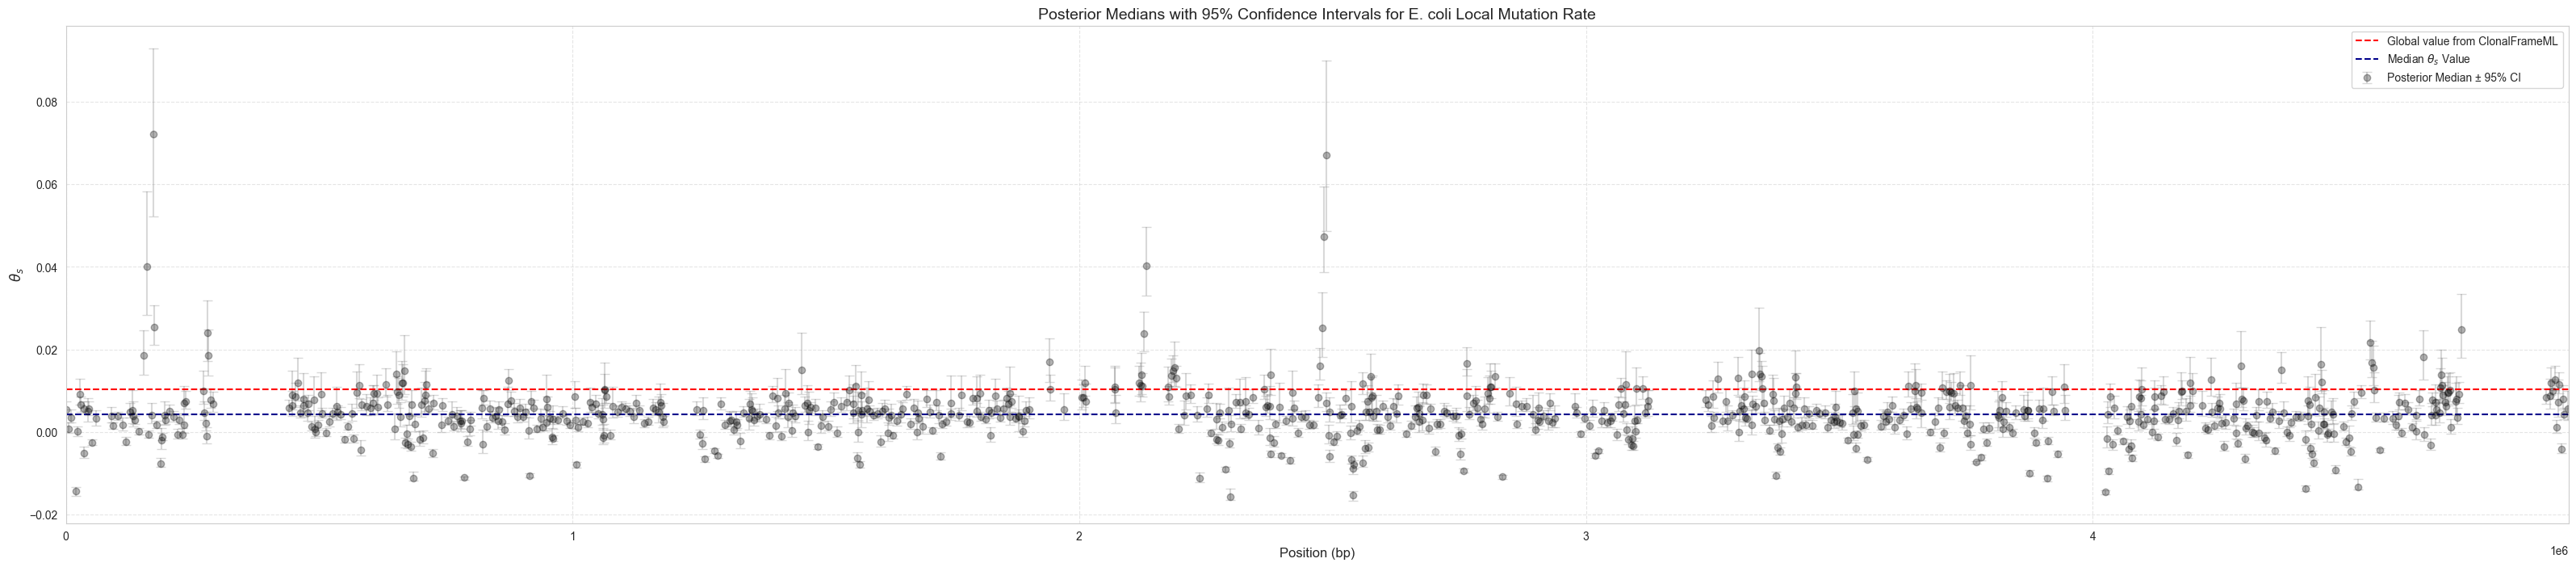

In [124]:
plt.figure(figsize=(40, 8))
plt.errorbar(samples_x, posterior_median_theta, yerr=yerr_theta, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, alpha=0.3,
             label='Posterior Median ± 95% CI')

plt.title("Posterior Medians with 95% Confidence Intervals for E. coli Local Mutation Rate", fontsize=14)
plt.xlabel("Position (bp)", fontsize=12)
plt.ylabel(r'$\theta_s$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(y=0.01033768239616971, color='red', linestyle='dashed', label='Global value from ClonalFrameML')
plt.axhline(y=median_theta, color='darkblue', linestyle='dashed', label=r'Median $\theta_s$ Value')
plt.xlim(plot_xlim)
plt.legend()
plt.show()

In [125]:
samples_l = x_obs_info_table['Gene_Length'].values
samples_l.shape

(836,)

In [126]:
posterior_l_median = np.median(theta_post[:, :, 2], axis=1)
posterior_l_median.shape

(836,)

In [127]:
ci_lower_bounds_l = np.percentile(theta_post[:, :, 2], 2.5, axis=1)
ci_upper_bounds_l = np.percentile(theta_post[:, :, 2], 97.5, axis=1)
ci_lower_bounds_l.shape, ci_upper_bounds_l.shape

((836,), (836,))

In [128]:
lower_l_errors = posterior_l_median - ci_lower_bounds_l
upper_l_errors = ci_upper_bounds_l - posterior_l_median
yerr_l = [lower_l_errors, upper_l_errors]

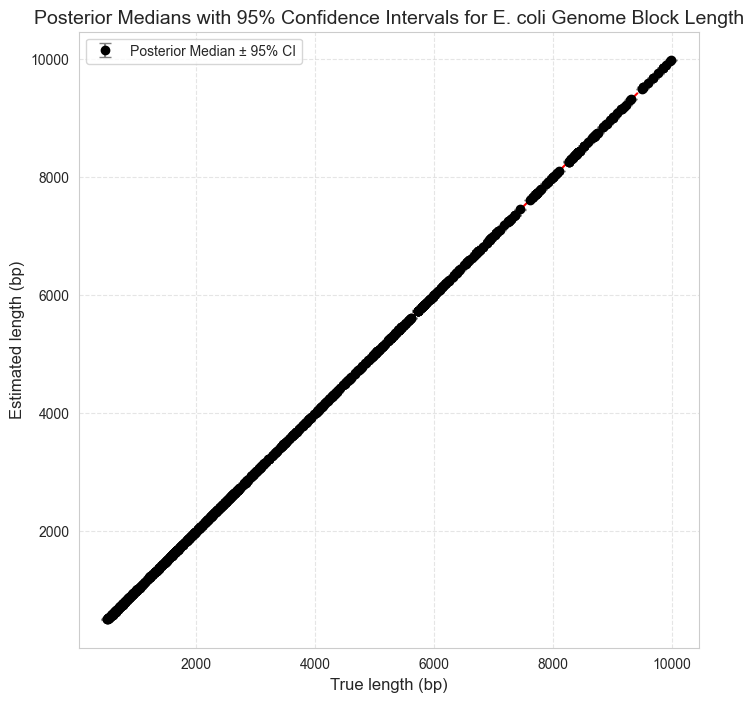

In [129]:
plt.figure(figsize=(8, 8))
plt.errorbar(samples_l, posterior_l_median, yerr=yerr_l, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, 
             label='Posterior Median ± 95% CI')

exact_x = np.linspace(np.min(samples_l), np.max(samples_l), 400)
exact_y = exact_x

plt.title("Posterior Medians with 95% Confidence Intervals for E. coli Genome Block Length", fontsize=14)
plt.xlabel("True length (bp)", fontsize=12)
plt.ylabel("Estimated length (bp)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.plot(exact_x, exact_y, color='red', linestyle='dashed')
plt.legend(loc='upper left')
plt.savefig('../output/ecoli_block_length.pdf', format='pdf', bbox_inches='tight')
plt.show()

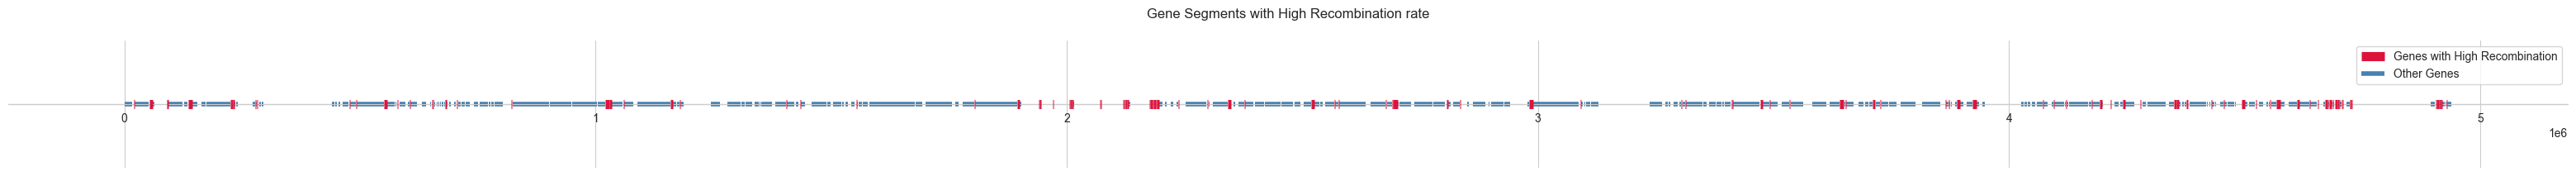

In [130]:
y_level = 0
gene_starts = np.delete(x_obs_info_table['Start_pos'].values, no_signal_id)
gene_ends   = np.delete(x_obs_info_table['End_pos'].values, no_signal_id)

high_recomb_index = np.where(ci_lower_bounds >= median_rho)[0]
highlight_starts = gene_starts[high_recomb_index]
highlight_ends   = gene_ends[high_recomb_index]

other_genes_index = np.where(ci_lower_bounds < median_rho)[0]
other_starts = gene_starts[other_genes_index]
other_ends   = gene_ends[other_genes_index]

fig, ax = plt.subplots(figsize=(40, 2))

ax.axhline(y=y_level, color='lightgray', linewidth=1, zorder=1)
ax.hlines(y=[y_level] * len(highlight_starts), xmin=highlight_starts, xmax=highlight_ends, 
          color='crimson', linewidth=8, label='Genes with High Recombination', zorder=3)
ax.hlines(y=[y_level] * len(other_starts), xmin=other_starts, xmax=other_ends, 
          color='steelblue', linewidth=4, label='Other Genes', zorder=2)

ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_position('center')

ax.set_ylim(-1, 1)
ax.set_title("Gene Segments with High Recombination rate", pad=20)
ax.legend(loc='upper right')
plt.show()

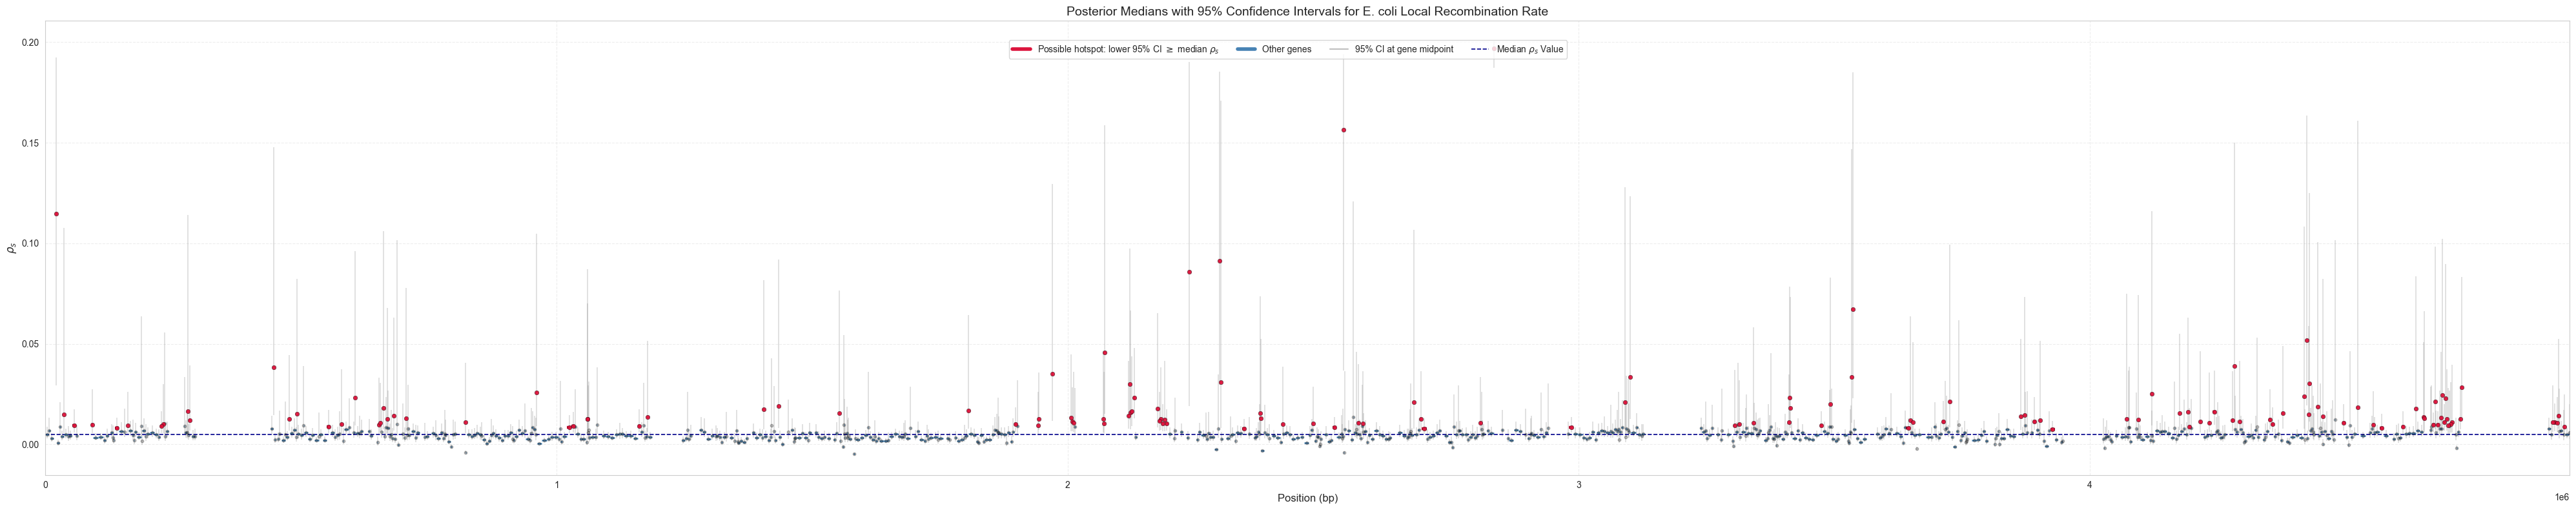

In [131]:
gene_starts = np.delete(x_obs_info_table['Start_pos'].values, no_signal_id)
gene_ends = np.delete(x_obs_info_table['End_pos'].values, no_signal_id)
gene_midpoints = (gene_starts + gene_ends) / 2

y = np.asarray(posterior_median)
is_hotspot = ci_lower_bounds >= median_rho
segments = [
    [(start, rate), (end, rate)]
    for start, end, rate in zip(gene_starts, gene_ends, y)
]

colors = np.where(is_hotspot, 'crimson', 'steelblue')
linewidths = np.where(is_hotspot, 3.2, 1.8)
alphas = np.where(is_hotspot, 0.95, 0.55)

fig, ax = plt.subplots(figsize=(40, 8))

# Plot gene intervals efficiently.
lc = LineCollection(
    segments,
    colors=colors,
    linewidths=linewidths,
    alpha=1.0,
    zorder=3,
)
ax.add_collection(lc)

# Add vertical CI bars at each gene midpoint.
# These retain the CI information from your original point/errorbar plot.
ax.vlines(
    gene_midpoints,
    ci_lower_bounds,
    ci_upper_bounds,
    colors='gray',
    linewidth=1.1,
    alpha=0.30,
    zorder=1,
)

# Add small midpoint markers to make exact median locations easier to see.
ax.scatter(
    gene_midpoints[~is_hotspot],
    y[~is_hotspot],
    s=10,
    color='black',
    alpha=0.25,
    zorder=4,
)
ax.scatter(
    gene_midpoints[is_hotspot],
    y[is_hotspot],
    s=22,
    color='crimson',
    edgecolor='black',
    linewidth=0.3,
    alpha=0.95,
    zorder=5,
)

# Reference lines from your original plot.
ax.axhline(
    y=median_rho,
    color='darkblue',
    linestyle='dashed',
    linewidth=1.2,
    label=r'Median $\rho_s$ Value',
    zorder=2,
)

# Labels and styling.
ax.set_title(
    'Posterior Medians with 95% Confidence Intervals for E. coli Local Recombination Rate',
    fontsize=14,
)
ax.set_xlabel('Position (bp)', fontsize=12)
ax.set_ylabel(r'$\rho_s$', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.35)
ax.set_xlim(plot_xlim)

# Set y limits with padding so CI bars are not clipped.
y_min = min(0, np.nanmin(ci_lower_bounds))
y_max = np.nanmax(ci_upper_bounds)
y_pad = 0.05 * (y_max - y_min)
ax.set_ylim(y_min - y_pad, y_max + y_pad)

# Custom legend for interval colors plus reference lines.
hotspot_handle = Line2D(
    [0], [0],
    color='crimson',
    lw=4,
    label=r'Possible hotspot: lower 95% CI $\geq$ median $\rho_s$',
)
other_handle = Line2D(
    [0], [0],
    color='steelblue',
    lw=4,
    label='Other genes',
)
ci_handle = Line2D(
    [0], [0],
    color='gray',
    lw=1.5,
    alpha=0.5,
    label='95% CI at gene midpoint',
)

reference_handles, reference_labels = ax.get_legend_handles_labels()
legend_handles = [hotspot_handle, other_handle, ci_handle] + reference_handles
legend_labels = [handle.get_label() for handle in legend_handles]

# A figure-level legend centered below the title.
fig.legend(
    legend_handles,
    legend_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.925),
    ncol=len(legend_handles),
    fontsize=10,
    frameon=True,
)

# Reserve the upper portion of the figure for the title and legend.
fig.tight_layout(rect=[0, 0, 1, 0.83])

plt.tight_layout()
plt.savefig('../output/ecoli_local_recomb.pdf', format='pdf', bbox_inches='tight')
plt.show()

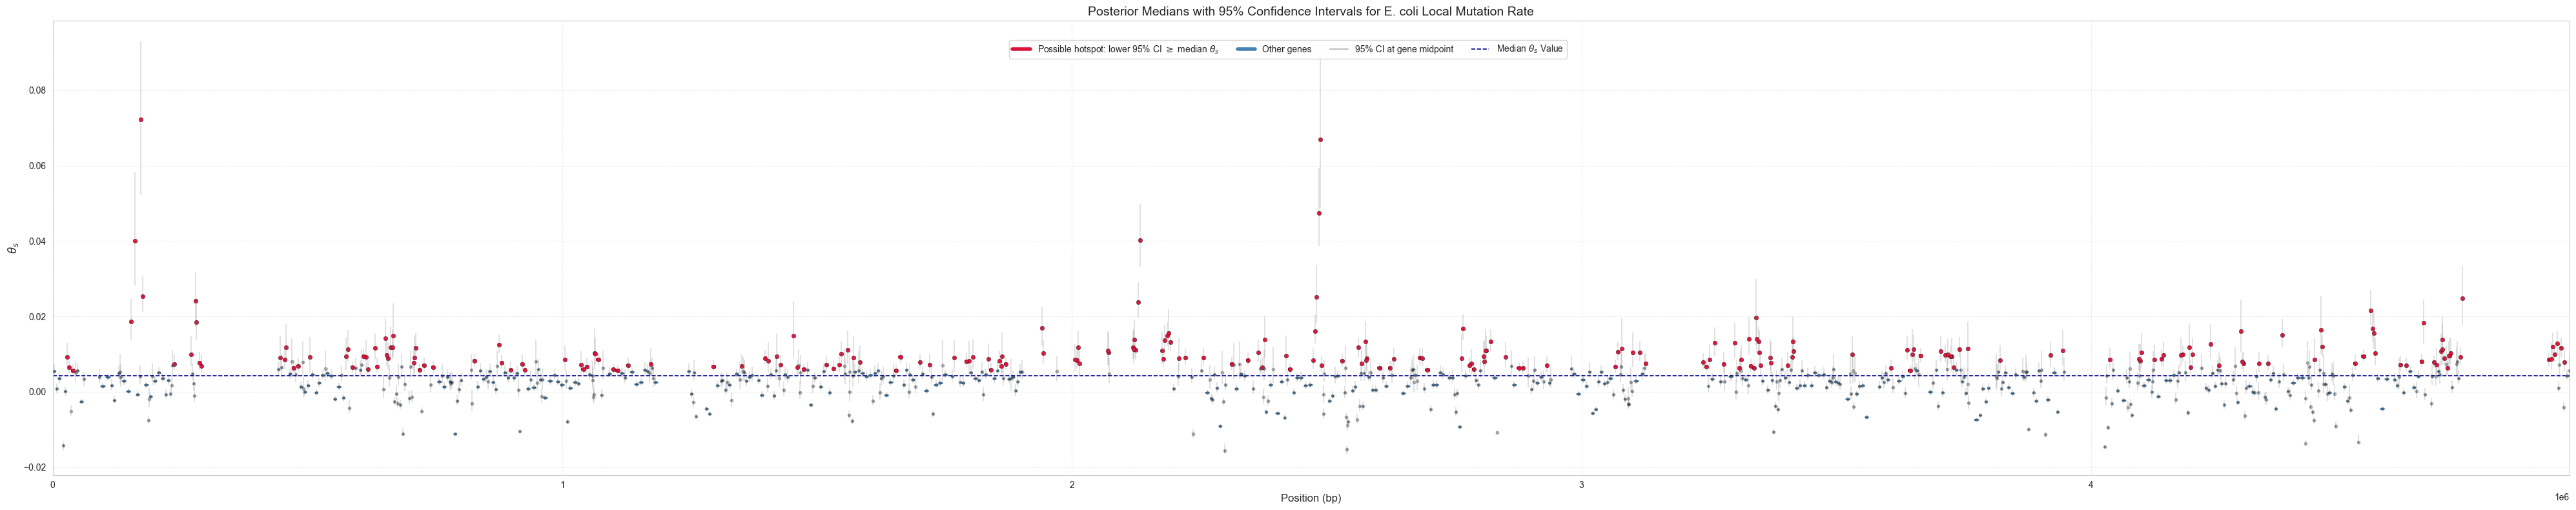

In [132]:
gene_starts = np.delete(x_obs_info_table['Start_pos'].values, no_signal_id)
gene_ends = np.delete(x_obs_info_table['End_pos'].values, no_signal_id)
gene_midpoints = (gene_starts + gene_ends) / 2

y = np.asarray(posterior_median_theta)
is_hotspot = ci_lower_bounds_theta >= median_theta
segments = [
    [(start, rate), (end, rate)]
    for start, end, rate in zip(gene_starts, gene_ends, y)
]

colors = np.where(is_hotspot, 'crimson', 'steelblue')
linewidths = np.where(is_hotspot, 3.2, 1.8)
alphas = np.where(is_hotspot, 0.95, 0.55)

fig, ax = plt.subplots(figsize=(40, 8))

# Plot gene intervals efficiently.
lc = LineCollection(
    segments,
    colors=colors,
    linewidths=linewidths,
    alpha=1.0,
    zorder=3,
)
ax.add_collection(lc)

# Add vertical CI bars at each gene midpoint.
# These retain the CI information from your original point/errorbar plot.
ax.vlines(
    gene_midpoints,
    ci_lower_bounds_theta,
    ci_upper_bounds_theta,
    colors='gray',
    linewidth=1.1,
    alpha=0.30,
    zorder=1,
)

# Add small midpoint markers to make exact median locations easier to see.
ax.scatter(
    gene_midpoints[~is_hotspot],
    y[~is_hotspot],
    s=10,
    color='black',
    alpha=0.25,
    zorder=4,
)
ax.scatter(
    gene_midpoints[is_hotspot],
    y[is_hotspot],
    s=22,
    color='crimson',
    edgecolor='black',
    linewidth=0.3,
    alpha=0.95,
    zorder=5,
)

# Reference lines from your original plot.
ax.axhline(
    y=median_theta,
    color='darkblue',
    linestyle='dashed',
    linewidth=1.2,
    label=r'Median $\theta_s$ Value',
    zorder=2,
)

# Labels and styling.
ax.set_title(
    'Posterior Medians with 95% Confidence Intervals for E. coli Local Mutation Rate',
    fontsize=14,
)
ax.set_xlabel('Position (bp)', fontsize=12)
ax.set_ylabel(r'$\theta_s$', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.35)
ax.set_xlim(plot_xlim)

# Set y limits with padding so CI bars are not clipped.
y_min = min(0, np.nanmin(ci_lower_bounds_theta))
y_max = np.nanmax(ci_upper_bounds_theta)
y_pad = 0.05 * (y_max - y_min)
ax.set_ylim(y_min - y_pad, y_max + y_pad)

# Custom legend for interval colors plus reference lines.
hotspot_handle = Line2D(
    [0], [0],
    color='crimson',
    lw=4,
    label=r'Possible hotspot: lower 95% CI $\geq$ median $\theta_s$',
)
other_handle = Line2D(
    [0], [0],
    color='steelblue',
    lw=4,
    label='Other genes',
)
ci_handle = Line2D(
    [0], [0],
    color='gray',
    lw=1.5,
    alpha=0.5,
    label='95% CI at gene midpoint',
)

reference_handles, reference_labels = ax.get_legend_handles_labels()
legend_handles = [hotspot_handle, other_handle, ci_handle] + reference_handles
legend_labels = [handle.get_label() for handle in legend_handles]

# A figure-level legend centered below the title.
fig.legend(
    legend_handles,
    legend_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.925),
    ncol=len(legend_handles),
    fontsize=10,
    frameon=True,
)

# Reserve the upper portion of the figure for the title and legend.
fig.tight_layout(rect=[0, 0, 1, 0.83])

plt.tight_layout()
plt.savefig('../output/ecoli_local_mutate.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [67]:
from hotspot_HMM import DistanceAwareHotspotHMM

In [68]:
ord_start_pos = np.argsort(gene_starts)
ord_end_pos = np.argsort(gene_ends)
print(np.all(ord_start_pos == ord_end_pos))

True


Estimated fold enrichment: 5.24x
Expected hotspot length: 5,412 bp


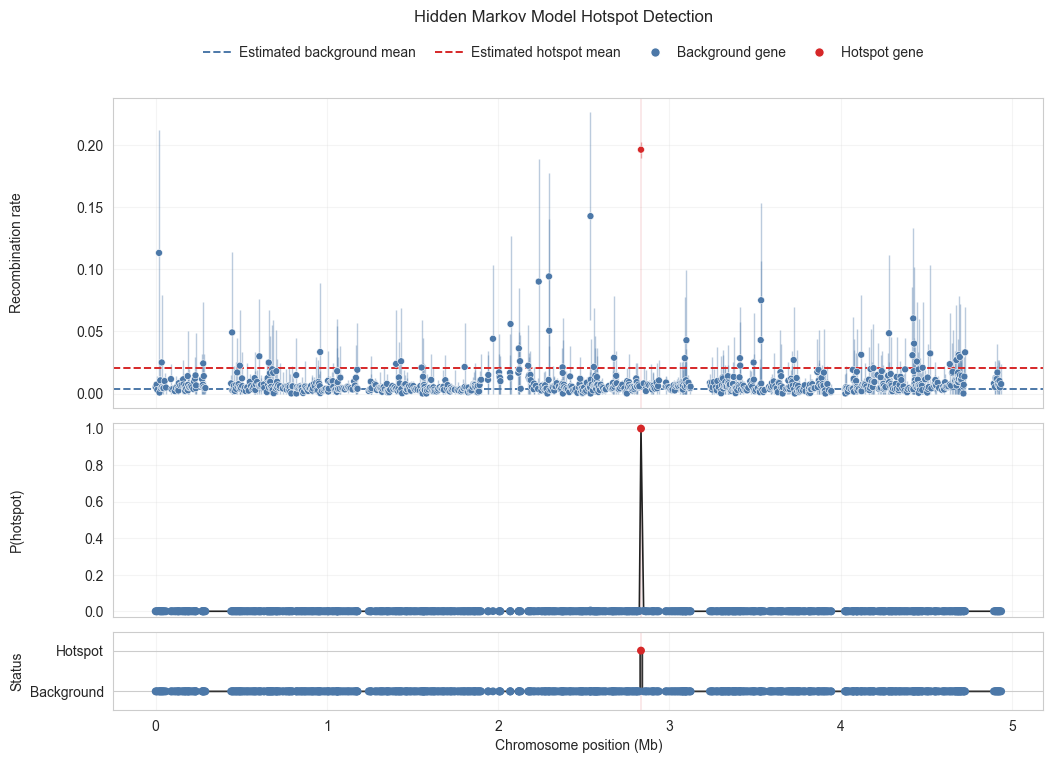

In [69]:
positions = gene_starts[ord_start_pos]

posterior_rate_draws = theta_post[ord_start_pos, :, 0]
indices_below_zero = np.where(posterior_rate_draws <= 0)
posterior_rate_draws[indices_below_zero] = np.finfo(np.float64).eps

model = DistanceAwareHotspotHMM(
    distance_unit_bp=1e5,
    min_fold_enrichment=5.0,
    n_starts=10,
    random_state=10,
)
result = model.fit(positions, posterior_samples=posterior_rate_draws)

print(f"Estimated fold enrichment: {result.fold_enrichment:.2f}x")
print(f"Expected hotspot length: {result.expected_hotspot_length:,.0f} bp")

# Plot rates, posterior hotspot probabilities, and the two-state path.
result.plot_states(
    position_unit_bp=1e6,
    position_unit_name="Mb",
    rate_label="Recombination rate",
    save_path="../output/ecoli_local_recomb_hmm.pdf"
)

plt.show()

In [70]:
from hotspot_DoG import DoGHotspotDetector

Detected hotspot segments:
  1.86-2.07 Mb; 21 genes; peak P=1.000; peak enrichment=8.39x
  2.82-2.87 Mb; 7 genes; peak P=0.967; peak enrichment=4.84x


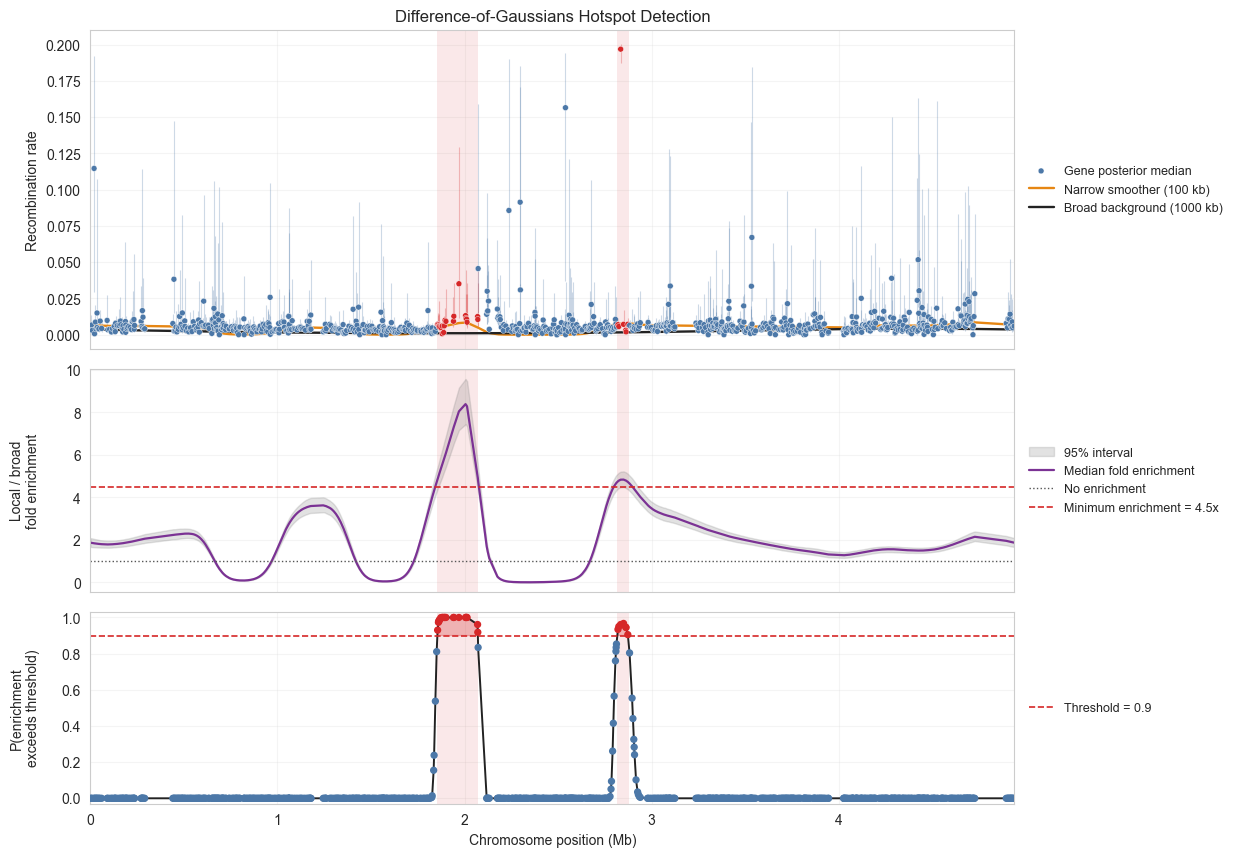

In [112]:
positions = gene_starts[ord_start_pos]
posterior_draws = theta_post[ord_start_pos, :, 0].transpose()
indices_below_zero = np.where(posterior_draws <= 0)
posterior_draws[indices_below_zero] = np.finfo(np.float64).eps

detector = DoGHotspotDetector(
    narrow_bandwidth_bp=100_000,
    broad_bandwidth_bp=1_000_000,
    min_fold_enrichment=4.5,
    probability_threshold=0.90,
    residual_log_sd=0.20,
    min_effective_genes=1.0,
    random_state=10,
    chromosome_length_bp=4_938_906
)
result = detector.fit(positions, posterior_draws)

print("Detected hotspot segments:")
for segment in result.segments(max_gap_bp=800_000):
    print(
        f"  {segment['start_position_bp'] / 1e6:.2f}-"
        f"{segment['end_position_bp'] / 1e6:.2f} Mb; "
        f"{segment['n_genes']} genes; "
        f"peak P={segment['peak_probability']:.3f}; "
        f"peak enrichment={segment['peak_fold_enrichment']:.2f}x"
    )

result.plot(
    rate_label="Recombination rate",
    save_path="../output/ecoli_local_recomb_dog.pdf"
)
plt.show()

Estimated fold enrichment: 20.00x
Expected hotspot length: 7,203 bp


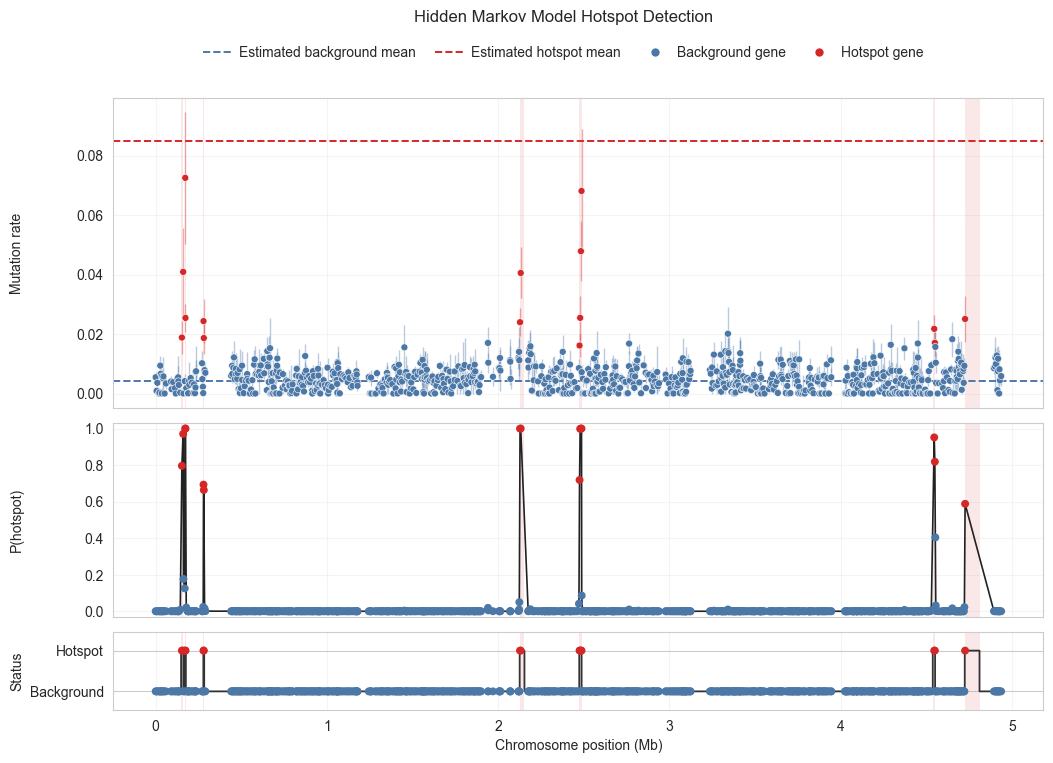

In [97]:
positions = gene_starts[ord_start_pos]

posterior_rate_draws = theta_post[ord_start_pos, :, 1]
indices_below_zero = np.where(posterior_rate_draws <= 0)
posterior_rate_draws[indices_below_zero] = np.finfo(np.float64).eps

model = DistanceAwareHotspotHMM(
    distance_unit_bp=1e5,
    min_fold_enrichment=20.0,
    n_starts=10,
    random_state=10,
)
result = model.fit(positions, posterior_samples=posterior_rate_draws)

print(f"Estimated fold enrichment: {result.fold_enrichment:.2f}x")
print(f"Expected hotspot length: {result.expected_hotspot_length:,.0f} bp")

# Plot rates, posterior hotspot probabilities, and the two-state path.
result.plot_states(
    position_unit_bp=1e6,
    position_unit_name="Mb",
    rate_label="Mutation rate",
    save_path="../output/ecoli_local_mutate_hmm.pdf"
)

plt.show()

Detected hotspot segments:
  0.27-0.29 Mb; 8 genes; peak P=1.000; peak enrichment=160.31x
  1.94-2.01 Mb; 7 genes; peak P=1.000; peak enrichment=148.92x
  2.78-2.86 Mb; 15 genes; peak P=1.000; peak enrichment=133.06x
  3.24-3.27 Mb; 7 genes; peak P=1.000; peak enrichment=133.40x
  4.72-4.73 Mb; 3 genes; peak P=1.000; peak enrichment=114.99x


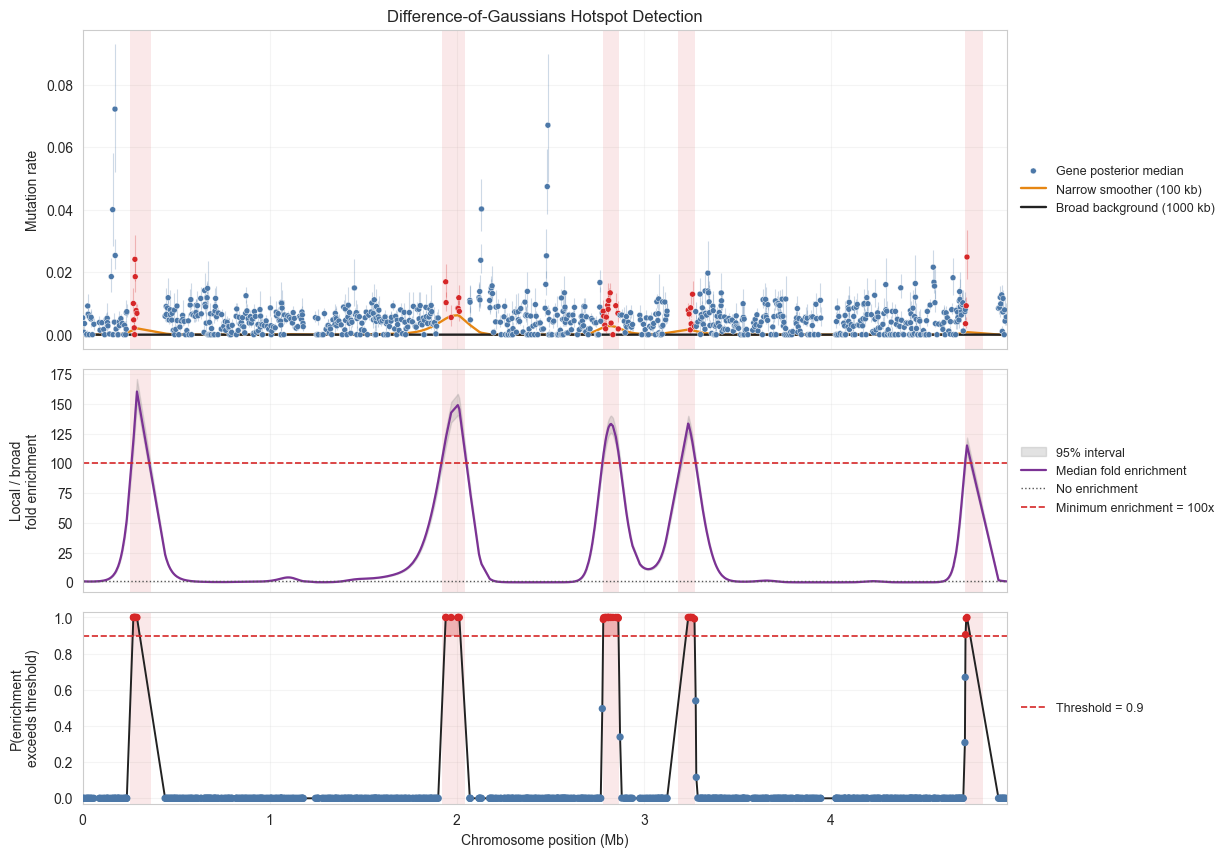

In [101]:
positions = gene_starts[ord_start_pos]
posterior_draws = theta_post[ord_start_pos, :, 1].transpose()
indices_below_zero = np.where(posterior_draws <= 0)
posterior_draws[indices_below_zero] = np.finfo(np.float64).eps

detector = DoGHotspotDetector(
    narrow_bandwidth_bp=100_000,
    broad_bandwidth_bp=1_000_000,
    min_fold_enrichment=100.0,
    probability_threshold=0.90,
    residual_log_sd=0.20,
    min_effective_genes=1.0,
    random_state=10,
    chromosome_length_bp=4_938_906
)
result = detector.fit(positions, posterior_draws)

print("Detected hotspot segments:")
for segment in result.segments(max_gap_bp=800_000):
    print(
        f"  {segment['start_position_bp'] / 1e6:.2f}-"
        f"{segment['end_position_bp'] / 1e6:.2f} Mb; "
        f"{segment['n_genes']} genes; "
        f"peak P={segment['peak_probability']:.3f}; "
        f"peak enrichment={segment['peak_fold_enrichment']:.2f}x"
    )

result.plot(
    rate_label="Mutation rate",
    save_path="../output/ecoli_local_mutate_dog.pdf"
)
plt.show()